# QuACK Microbenchmarks

In [1]:
from common import *
from typing import Dict, List, Optional
import re
import math
import matplotlib.pyplot as plt

## Collect data

```
# Make the data directory
export SIDEKICK_HOME=$HOME/sidekick-downloads
cd $SIDEKICK_HOME
export DATA_HOME=$SIDEKICK_HOME/data/quack
mkdir -p $DATA_HOME

# Run the quACK microbenchmarks for encode and decode
cd deps/quack/
cargo build --release --example benchmark_riblt
./target/release/examples/benchmark_riblt power-sum --encode > $DATA_HOME/psum_encode.log
./target/release/examples/benchmark_riblt power-sum --decode > $DATA_HOME/psum_decode.log
./target/release/examples/benchmark_riblt iblt --encode > $DATA_HOME/iblt_encode.log
./target/release/examples/benchmark_riblt iblt --decode > $DATA_HOME/iblt_decode.log

# Run the quACK microbenchmarks for IBLT correctness
cargo build --release --example benchmark_riblt_multiplier
./target/release/examples/benchmark_riblt_multiplier > $DATA_HOME/iblt_multiplier.log
```

## Parse data

In [2]:
QUACK_TYPES = ['Power Sum', 'IBLT']

In [3]:
def add_encode_data(final_data, quack_ty, filename, print_log=False):
    data = { 'xs': [], 'ys': [] }
    with open(filename) as f:
        lines = f.readlines()
    for line in lines:
        if print_log:
            print(line, end='')
        match = re.search(r'Encode/m=(\d+)\s+\d+\s+(\d+)ns/op', line)
        if match:
            num_symbols = int(match.group(1))
            ns_per_op = int(match.group(2))
            data['xs'].append(num_symbols)
            data['ys'].append(ns_per_op)
    final_data[quack_ty] = data

def parse_encode_data():
    data = {}
    add_encode_data(data, 'Power Sum', f'{SIDEKICK_HOME}/data/quack/psum_encode.log')
    add_encode_data(data, 'IBLT', f'{SIDEKICK_HOME}/data/quack/iblt_encode.log')
    return data

In [4]:
def add_decode_data(final_data, quack_ty, filename, print_log=False):
    data = { 'xs': [], 'ys': [] }
    with open(filename) as f:
        lines = f.readlines()
    for line in lines:
        if print_log:
            print(line, end='')
        match = re.search(r'Decode/d=(\d+)\s+\d+\s+(\d+)ns/op', line)
        if match:
            num_missing = int(match.group(1))
            ns_per_op = int(match.group(2))
            data['xs'].append(num_missing)
            data['ys'].append(ns_per_op / 1000)
    final_data[quack_ty] = data

def parse_decode_data():
    data = {}
    add_decode_data(data, 'Power Sum', f'{SIDEKICK_HOME}/data/quack/psum_decode.log')
    add_decode_data(data, 'IBLT', f'{SIDEKICK_HOME}/data/quack/iblt_decode.log')
    return data

In [5]:
def add_multiplier_data(final_data, num_missing, num_symbols):
    data = {}
    data['xs'] = [n / num_missing for n in num_symbols]
    n = len(num_symbols)
    data['ys'] = [100 * i / n for i in range(1, n+1)]
    final_data[num_missing] = data

def parse_multiplier_data():
    data = {}
    filename = f'{SIDEKICK_HOME}/data/quack/iblt_multiplier.log'
    with open(filename) as f:
        lines = f.readlines()
    for line in lines:
        match = re.search(r'Multiplier/d=(\d+)\s+\d+\s+([\d,]+)', line)
        if match:
            num_missing = int(match.group(1))
            num_symbols = list(map(int, match.group(2).split(',')))
            add_multiplier_data(data, num_missing, num_symbols)
    return data

## Plot data

### Plot functions

In [6]:
def plot_line_graph(data: Dict, keys: List, labels: List[str], xlabel: str, ylabel: str, logscale: bool,
                    xlim, ylim, figsize=(3, 2), title: Optional[str]=None, pdf: Optional[str]=None):
    plt.figure(figsize=figsize)
    for i, key in enumerate(keys):
        value = data.get(key)
        label = labels[i]
        if not value:
            continue
        plt.plot(value['xs'], value['ys'], label=label)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if logscale:
        plt.xscale('log')
        plt.yscale('log')
    plt.grid()
    plt.xlim(xlim)
    plt.ylim(ylim)
    ncol = 3
    legend_height = 1.25
    legend_height += 0.15 * (math.ceil(len(labels) / ncol) - 1)
    if title:
        plt.title(title)
        legend_height += 0.15
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, legend_height), ncol=ncol)
    if pdf:
        save_pdf(pdf)
    plt.show()

In [7]:
def plot_quack_encode(data, keys, title='', pdf=None):
    plot_line_graph(
        data,
        keys=keys,
        labels=keys,
        logscale=True,
        xlim=1,
        ylim=1,
        xlabel='Num Symbols',
        ylabel='Time (ns/packet)',
        title=title,
        pdf=pdf,
    )

In [8]:
def plot_quack_decode(data, keys, title='', pdf=None):
    plot_line_graph(
        data,
        keys=keys,
        labels=keys,
        logscale=True,
        xlim=1,
        ylim=0.1,
        xlabel='Num Missing',
        ylabel='Time (μs)',
        title=title,
        pdf=pdf,
    )

In [9]:
def plot_iblt_correctness(data, keys, title='', pdf=None):
    plot_line_graph(
        data,
        figsize=(5,2),
        keys=keys,
        labels=[f'm={m}' for m in keys],
        logscale=False,
        xlim=0.9,
        ylim=(0, 100),
        xlabel='Multiplier (Num Symbols / Num Errors)',
        ylabel='% Decode Success',
        title=title,
        pdf=pdf,
    )

### Plot results

../figures/quack_encode.pdf


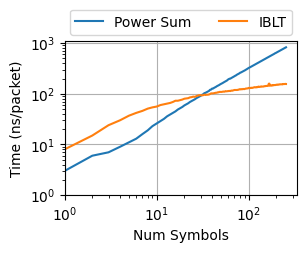

In [10]:
encode_data = parse_encode_data()
plot_quack_encode(encode_data, QUACK_TYPES, pdf='../figures/quack_encode.pdf')

../figures/quack_decode.pdf


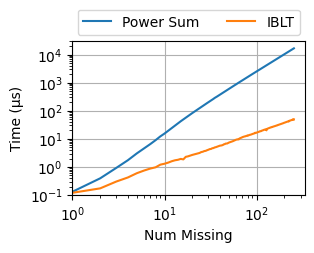

In [11]:
decode_data = parse_decode_data()
plot_quack_decode(decode_data, QUACK_TYPES, pdf='../figures/quack_decode.pdf')

../figures/quack_multiplier.pdf


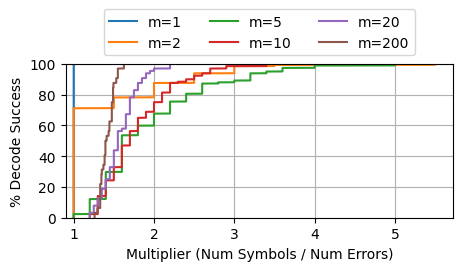

In [12]:
multiplier_data = parse_multiplier_data()
plot_iblt_correctness(multiplier_data, [1, 2, 5, 10, 20, 200], pdf='../figures/quack_multiplier.pdf')